In [170]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [171]:
df = pd.read_csv("placement.csv")

In [172]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Text(0, 0.5, 'Package(lpa)')

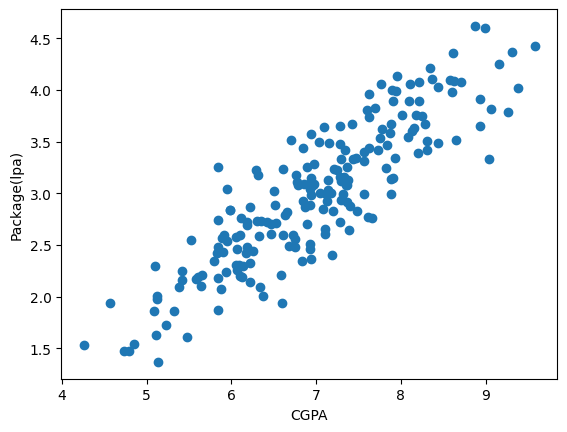

In [173]:
plt.scatter(df['cgpa'],df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package(lpa)')

In [174]:
x=df.iloc[:,0:1]

In [175]:
x

,cgpa
0,6.89
1,5.12
2,7.82
3,7.42
4,6.94
...,...
195,6.93
196,5.89
197,7.21
198,7.63


In [176]:
y=df.iloc[:,-1]

In [177]:
y

0      3.26
1      1.98
2      3.25
3      3.67
4      3.57
       ... 
195    2.46
196    2.57
197    3.24
198    3.96
199    2.33
Name: package, Length: 200, dtype: float64

In [178]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [179]:
from sklearn.linear_model import LinearRegression

In [180]:
lr = LinearRegression()

In [181]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Text(0, 0.5, 'Package(lpa)')

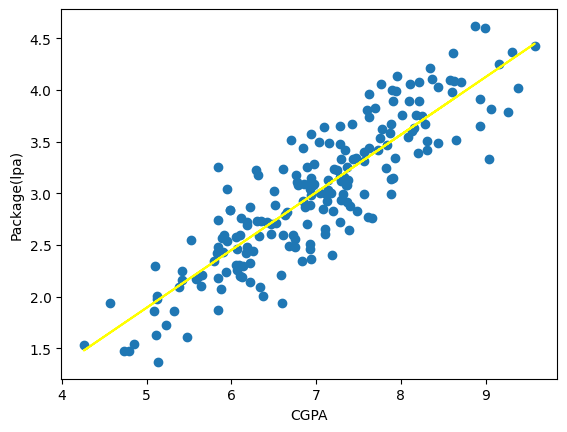

In [182]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(X_train,lr.predict(X_train),color='yellow')
plt.xlabel('CGPA')
plt.ylabel('Package(lpa)')

In [183]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [184]:
y_pred=lr.predict(X_test)

In [185]:
y_test.values

array([4.1 , 3.49, 2.08, 2.33, 1.94, 1.48, 1.86, 3.09, 4.21, 2.87, 3.65,
       4.  , 2.89, 2.6 , 2.99, 3.25, 1.86, 3.67, 2.37, 3.42, 2.48, 3.65,
       2.6 , 2.83, 4.08, 2.56, 3.58, 3.81, 4.09, 2.01, 3.63, 2.92, 3.51,
       1.94, 2.21, 3.34, 3.34, 3.23, 2.01, 2.61])

In [186]:
print("MAE",mean_absolute_error(y_test,y_pred))

MAE 0.2884710931878175


In [187]:
print("MsE",mean_squared_error(y_test,y_pred))

MsE 0.12129235313495527


In [188]:
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred)))

RMSE 0.34827051717731616


In [189]:
print("R2_score",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

R2_score 0.780730147510384


In [190]:
#adjusted r2 score:
X_test.shape

(40, 1)

In [191]:
1-((1-r2)*(40-1)/(40-1-1))

0.7749598882343415

> adj R2 operation

> irrelevent colum

In [192]:
new_df1 = df.copy()
new_df1['random_feature']=np.random.random(200)

new_df1 = new_df1[['cgpa','random_feature','package']]
new_df1.head()

,cgpa,random_feature,package
0,6.89,0.471816,3.26
1,5.12,0.040048,1.98
2,7.82,0.993498,3.25
3,7.42,0.515292,3.67
4,6.94,0.449738,3.57


Text(0, 0.5, 'package(lpa)')

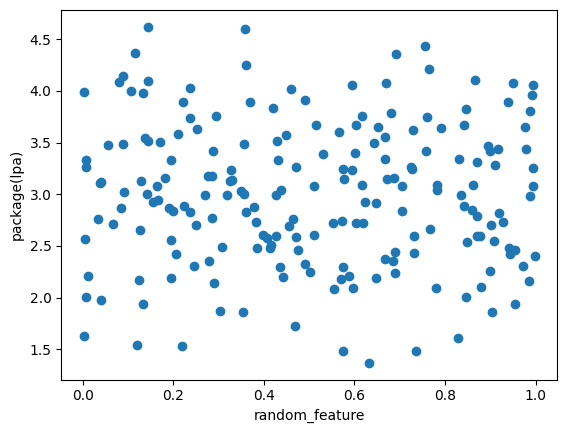

In [193]:
plt.scatter(new_df1['random_feature'],new_df1['package'])
plt.xlabel('random_feature')
plt.ylabel('package(lpa)')

In [194]:
x = new_df1.iloc[:,0:1]
y=new_df1.iloc[:,-1]

In [195]:
x

,cgpa
0,6.89
1,5.12
2,7.82
3,7.42
4,6.94
...,...
195,6.93
196,5.89
197,7.21
198,7.63


In [196]:
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [197]:
lr = LinearRegression()

In [198]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [199]:
y_pred = lr.predict(X_test)

In [200]:
print("R2_score",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

R2_score 0.780730147510384


In [201]:
1-((1-r2)*(40-1)/(40-1-2))

0.7688777230514858

>new relevent column 

In [205]:
new_df2 = df.copy()
new_df2['iq'] = new_df2['package']+(np.random.randint(-12,12,200)/10)
new_df2 = new_df2[['cgpa','iq','package']]

In [206]:
new_df2.head()

,cgpa,iq,package
0,6.89,3.76,3.26
1,5.12,2.18,1.98
2,7.82,3.95,3.25
3,7.42,3.97,3.67
4,6.94,4.17,3.57


Text(0, 0.5, 'package(lpa)')

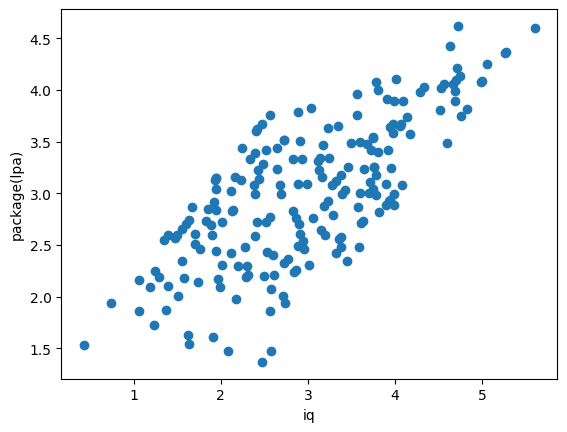

In [208]:
plt.scatter(new_df2['iq'],new_df2['package'])
plt.xlabel('iq')
plt.ylabel('package(lpa)')

In [209]:
np.random.randint(-100,100)

-88

In [211]:
x = new_df2.iloc[:,0:2]
y=new_df2.iloc[:,-1]

In [213]:
X_train, X_test, y_train, y_test = train_test_split(x, y,
                                                    test_size=0.2,
                                                    random_state=2)

In [214]:
lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)

In [215]:
print("R2 score",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

R2 score 0.8084778182746472


In [216]:
1 - ((1-r2)*(40-1)/(40-1-2))

0.7981252679111146